# MaldiAMRKit - Differential Analysis

This notebook demonstrates the `maldiamrkit.differential` module for identifying
m/z bins that differ significantly between **resistant (R)** and **susceptible (S)**
groups, and for comparing significant peaks across multiple drugs.

It covers:
- `DifferentialAnalysis` on a binned feature matrix (Mann-Whitney U or Welch's t-test)
- Multiple-testing correction (FDR-BH, FDR-BY, Bonferroni), log2 fold change, Cohen's d
- Ranking peaks with `top_peaks()` and filtering with `significant_peaks()`
- AMR-aware plots: `plot_volcano`, `plot_manhattan`
- Multi-drug comparison via `compare_drugs` + `plot_drug_comparison` (heatmap / UpSet)

## Load the Dataset

We reuse the small example dataset bundled with MaldiAMRKit (29 spectra
with an `R` / `S` resistance label in the `Drug` metadata column).

In [1]:
from maldiamrkit import MaldiSet

data = MaldiSet.from_directory(
    "../data/",
    "../data/metadata/metadata.csv",
    aggregate_by=dict(antibiotics="Drug"),
    bin_width=3,
)
print(data)
print(f"X shape: {data.X.shape}")

/home/ettore/.venvs/maldiamrkit/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


MaldiSet(n_spectra=29, species='all', antibiotics=['Drug'])
X shape: (29, 6000)


## Prepare Binary Labels

`DifferentialAnalysis` expects a binary `y` with `0` = susceptible and `1` = resistant.
We map the string labels via `LabelEncoder` and keep the feature matrix aligned.

In [2]:
import pandas as pd

from maldiamrkit.evaluation import LabelEncoder

encoder = LabelEncoder(intermediate="drop")
labels_raw = data.get_y_single("Drug")
y_arr = encoder.fit_transform(labels_raw)
y = pd.Series(y_arr, index=labels_raw.index, name="y").dropna().astype(int)
X = data.X.loc[y.index]

print("Class counts:", y.value_counts().to_dict())

Class counts: {0: 19, 1: 10}


## Augment the Dataset (Demo Only)

The bundled example has only 29 spectra, which isn't enough to produce
visually rich volcano / Manhattan plots. For teaching purposes we append
**synthetic spectra** with:

- Gaussian noise on top of the mean real spectrum (so the baseline shape
  looks like real MALDI data)
- A handful of m/z bins that are boosted in the resistant class and a
  handful boosted in the susceptible class (the "true" differential peaks)
- Per-row TIC normalization so synthetic spectra sum to 1, matching the
  preprocessing of the real rows

This is a **notebook-only trick to get clearer plots** - never use this
synthetic augmentation in a real analysis.

In [ ]:
import numpy as np


def synthesize_spectra(
    template_row: pd.Series,
    n_samples: int,
    r_boost_bins: list[str],
    s_boost_bins: list[str],
    boost_strength: float,
    noise_scale: float,
    labels: np.ndarray,
    random_state: int,
) -> pd.DataFrame:
    """Generate synthetic spectra by adding noise to a template row and boosting specific bins."""
    rng = np.random.default_rng(random_state)
    base = template_row.to_numpy()
    noise = rng.normal(0.0, noise_scale * base.mean(), size=(n_samples, base.size))
    synth = np.clip(base + noise, 0.0, None)
    for bin_name in r_boost_bins:
        j = template_row.index.get_loc(bin_name)
        synth[labels == 1, j] += boost_strength * base.mean()
    for bin_name in s_boost_bins:
        j = template_row.index.get_loc(bin_name)
        synth[labels == 0, j] += boost_strength * base.mean()
    # TIC-normalize each row
    synth = synth / synth.sum(axis=1, keepdims=True)
    return pd.DataFrame(synth, columns=template_row.index)


rng = np.random.default_rng(42)
n_synth = 100
synth_labels = rng.integers(0, 2, size=n_synth)

# Pick a few m/z bins to act as "true" differential peaks
candidate_bins = list(X.columns)
r_bins = list(rng.choice(candidate_bins, size=6, replace=False))
s_bins = list(
    rng.choice([c for c in candidate_bins if c not in r_bins], size=6, replace=False)
)
print(f"Injected R-specific bins: {r_bins}")
print(f"Injected S-specific bins: {s_bins}")

X_synth = synthesize_spectra(
    template_row=X.mean(),
    n_samples=n_synth,
    r_boost_bins=r_bins,
    s_boost_bins=s_bins,
    boost_strength=80.0,
    noise_scale=0.25,
    labels=synth_labels,
    random_state=42,
)
X_synth.index = [f"synth_{i}" for i in range(n_synth)]
y_synth = pd.Series(synth_labels, index=X_synth.index, name="y")

# Append synthetic rows to the real matrix
X = pd.concat([X, X_synth])
y = pd.concat([y, y_synth]).astype(int)
assert np.allclose(X.sum(axis=1), 1.0)
print(f"Augmented dataset: X={X.shape}, class counts={y.value_counts().to_dict()}")

Injected R-specific bins: [np.str_('16163.0'), np.str_('16976.0'), np.str_('16478.0'), np.str_('5594.0'), np.str_('2132.0'), np.str_('16340.0')]
Injected S-specific bins: [np.str_('11093.0'), np.str_('10253.0'), np.str_('12230.0'), np.str_('2672.0'), np.str_('11990.0'), np.str_('16031.0')]
Augmented dataset: X=(129, 6000), class counts={0: 67, 1: 62}


## Run the Differential Analysis

Instantiate `DifferentialAnalysis` with `X` and `y` and call `.run()`.
The default test is Mann-Whitney U (non-parametric, recommended for MALDI peak
intensities) with Benjamini-Hochberg FDR correction.

In [4]:
from maldiamrkit.differential import DifferentialAnalysis

analysis = DifferentialAnalysis(X, y).run(
    test="mann_whitney",
    correction="fdr_bh",
)
analysis.results.sort_values("adjusted_p_value", ascending=True).head()

,mz_bin,mean_r,mean_s,fold_change,p_value,adjusted_p_value,effect_size
4780,16340.0,0.010394,0.000066,7.297076,2.594608e-18,1.556765e-14,3.268696
4721,16163.0,0.010407,0.000070,7.210103,2.110777e-17,6.332330e-14,3.267646
4826,16478.0,0.010398,0.000063,7.364606,3.040948e-16,6.081895e-13,3.262958
4992,16976.0,0.010403,0.000073,7.152162,1.091686e-15,1.637529e-12,3.260642
1198,5594.0,0.010430,0.000110,6.572977,4.873563e-14,5.848276e-11,3.249831


The `results` table has one row per m/z bin with:

- `mz_bin` - the bin label (m/z value as stored in `X.columns`)
- `mean_r`, `mean_s` - mean intensity in each group
- `fold_change` - `log2((mean_r + eps) / (mean_s + eps))`
- `p_value` - raw test p-value
- `adjusted_p_value` - p-value after multiple-testing correction
- `effect_size` - Cohen's d between the two groups

### Construct directly from a `MaldiSet`

When the dataset's antibiotic column already stores numeric binary labels
(`0` / `1`), you can skip the manual `X` / `y` extraction:

```python
analysis = DifferentialAnalysis.from_maldi_set(
    data, antibiotic="Drug"
).run()
```

In the example dataset here the labels are the strings `"R"` / `"S"`, so we
keep the explicit `LabelEncoder` step above.

In [5]:
from maldiamrkit.detection import MaldiPeakDetector

analysis = DifferentialAnalysis(X, y).run(
    test="mann_whitney",
    correction="fdr_bh",
)
print(f"{len(analysis.results)} bins tested")
print(f"Smallest adjusted p-value: {analysis.results['adjusted_p_value'].min():.3e}")
print(f"#adj <= 0.05: {(analysis.results['adjusted_p_value'] <= 0.05).sum()}")

6000 bins tested
Smallest adjusted p-value: 1.557e-14
#adj <= 0.05: 12


Now `adjusted_p_value` has real variation and the downstream calls
work with meaningful significance cutoffs.

In [6]:
analysis.top_peaks(n=10)

,mz_bin,mean_r,mean_s,fold_change,p_value,adjusted_p_value,effect_size
4780,16340.0,0.010394,0.000066,7.297076,2.594608e-18,1.556765e-14,3.268696
4721,16163.0,0.010407,0.000070,7.210103,2.110777e-17,6.332330e-14,3.267646
4826,16478.0,0.010398,0.000063,7.364606,3.040948e-16,6.081895e-13,3.262958
4992,16976.0,0.010403,0.000073,7.152162,1.091686e-15,1.637529e-12,3.260642
1198,5594.0,0.010430,0.000110,6.572977,4.873563e-14,5.848276e-11,3.249831
44,2132.0,0.010612,0.000309,5.100953,8.662866e-14,8.662866e-11,3.239780
4677,16031.0,0.000077,0.008907,-6.846307,5.595244e-13,4.795923e-10,-2.190191
3330,11990.0,0.000082,0.008912,-6.771980,3.398893e-12,2.549169e-09,-2.190224
3410,12230.0,0.000092,0.008921,-6.603906,4.152701e-12,2.768467e-09,-2.191046
2751,10253.0,0.000230,0.009056,-5.300993,5.241508e-12,3.144905e-09,-2.192032


In [7]:
sig = analysis.significant_peaks(fc_threshold=1.0, p_threshold=0.05)
print(f"{len(sig)} peaks survive |log2FC| >= 1 and adj.p <= 0.05")
sig

12 peaks survive |log2FC| >= 1 and adj.p <= 0.05


,mz_bin,mean_r,mean_s,fold_change,p_value,adjusted_p_value,effect_size
0,2132.0,0.010612,0.000309,5.100953,8.662866e-14,8.662866e-11,3.239780
1,2672.0,0.000372,0.009185,-4.624326,1.015642e-09,5.078209e-07,-2.187739
2,5594.0,0.010430,0.000110,6.572977,4.873563e-14,5.848276e-11,3.249831
3,10253.0,0.000230,0.009056,-5.300993,5.241508e-12,3.144905e-09,-2.192032
4,11093.0,0.000060,0.008882,-7.211550,5.748468e-11,3.135528e-08,-2.184516
5,11990.0,0.000082,0.008912,-6.771980,3.398893e-12,2.549169e-09,-2.190224
6,12230.0,0.000092,0.008921,-6.603906,4.152701e-12,2.768467e-09,-2.191046
7,16031.0,0.000077,0.008907,-6.846307,5.595244e-13,4.795923e-10,-2.190191
8,16163.0,0.010407,0.000070,7.210103,2.110777e-17,6.332330e-14,3.267646
9,16340.0,0.010394,0.000066,7.297076,2.594608e-18,1.556765e-14,3.268696


## Volcano Plot

`plot_volcano` shows log2 fold change on the x axis and -log10(adjusted p-value)
on the y axis. Points are coloured by direction:

- red: up in resistant (`fold_change > fc_threshold` and `adj.p <= p_threshold`)
- blue: up in susceptible (`fold_change < -fc_threshold` and `adj.p <= p_threshold`)
- grey: non-significant

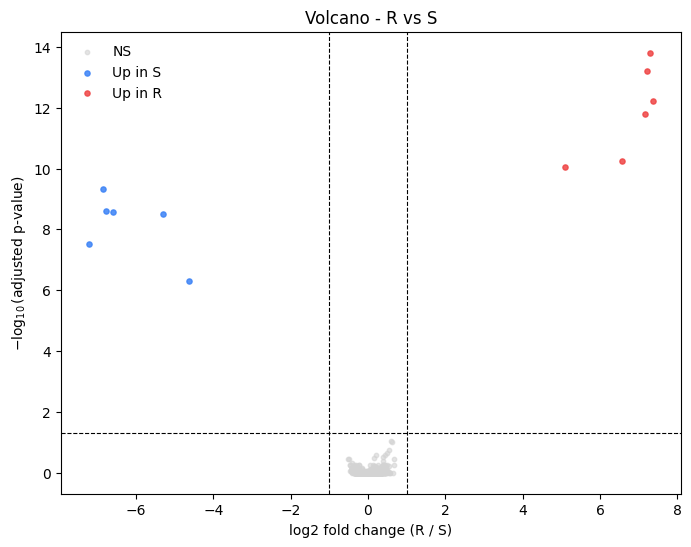

In [8]:
from maldiamrkit.differential import plot_volcano

_ = plot_volcano(
    analysis.results,
    fc_threshold=1.0,
    p_threshold=0.05,
    title="Volcano - R vs S",
)

## Manhattan Plot along the m/z Axis

`plot_manhattan` places each bin at its m/z position and plots
-log10(adjusted p-value). Points above the dashed line pass the
significance threshold.

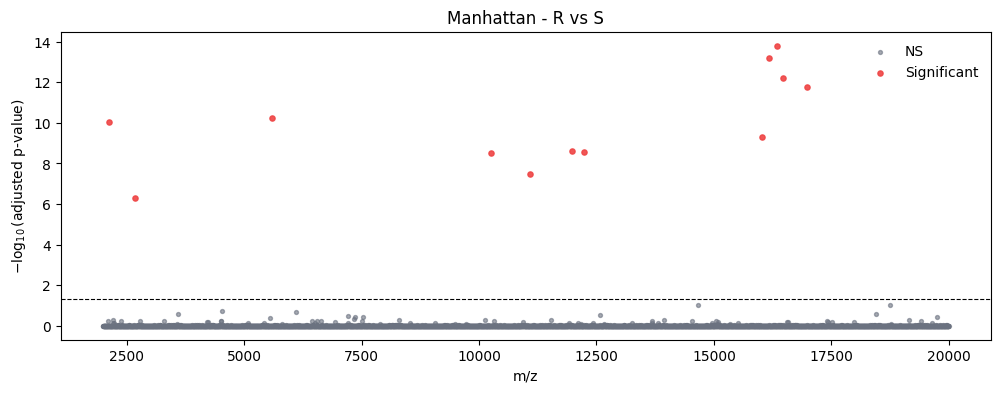

In [9]:
from maldiamrkit.differential import plot_manhattan

_ = plot_manhattan(
    analysis.results,
    p_threshold=0.05,
    title="Manhattan - R vs S",
)

## Compare across Multiple Drugs

`DifferentialAnalysis.compare_drugs` returns a boolean matrix whose rows are
the **union of significant m/z bins** across all drugs and whose columns are
drug names. `True` means the peak is significant for that drug.

The example dataset has a single drug, so to illustrate the API we build
two analyses against slightly different label views: the original `Drug`
column, and a randomly shuffled version. The shuffled analysis serves as
a "negative control" - we expect few or no peaks to survive correction.

In [10]:
# Two analyses on the same X: one with the real labels, one with
# shuffled labels (a "negative control" - should produce few or no
# significant peaks after correction).
rng = np.random.default_rng(0)
y_shuffled = y.sample(frac=1.0, random_state=0).reset_index(drop=True)
y_shuffled.index = y.index

analysis_real = DifferentialAnalysis(X, y).run()
analysis_null = DifferentialAnalysis(X, y_shuffled).run()

comparison = DifferentialAnalysis.compare_drugs(
    {"Drug (real)": analysis_real, "Drug (shuffled)": analysis_null},
    fc_threshold=1.0,
    p_threshold=0.05,
)
print(f"Union of significant bins: {len(comparison)}")
print("Per-drug counts:")
print(comparison.sum())

Union of significant bins: 12
Per-drug counts:
Drug (real)        12
Drug (shuffled)     0
dtype: int64


### Boolean Heatmap

`plot_drug_comparison(..., kind="heatmap")` renders a compact peaks x drugs
matrix - useful for spotting drug-specific peaks at a glance.

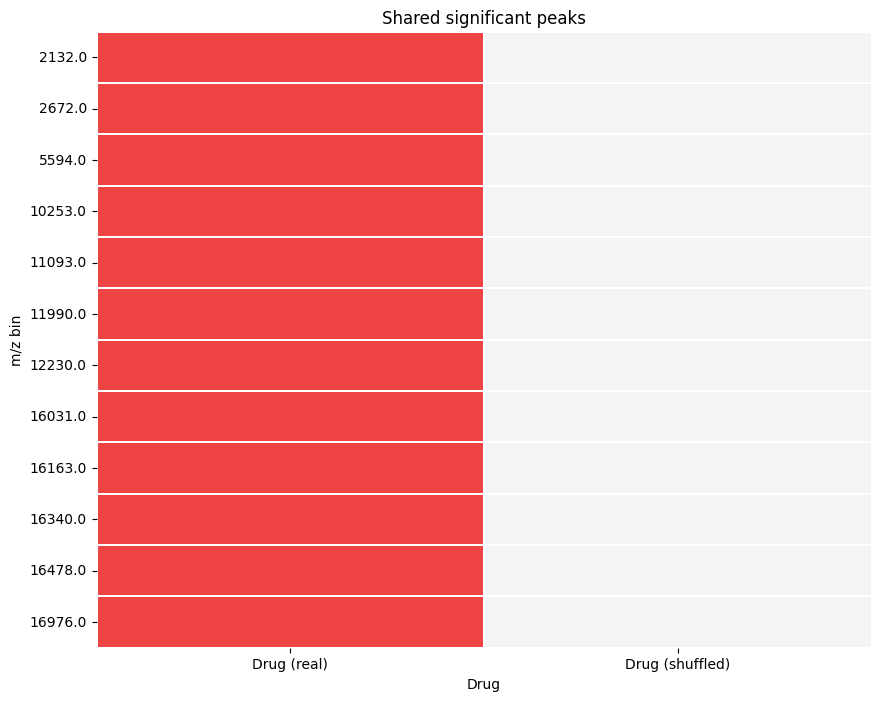

In [11]:
from maldiamrkit.differential import plot_drug_comparison

_ = plot_drug_comparison(comparison, kind="heatmap", title="Shared significant peaks")

### UpSet-style Intersection Plot

With more than two drugs, a Venn diagram stops scaling - an UpSet plot
shows the size of every intersection of significant-peak sets. Rows are
drugs, columns are intersections, and the top bar chart gives the count
of peaks in each combination.

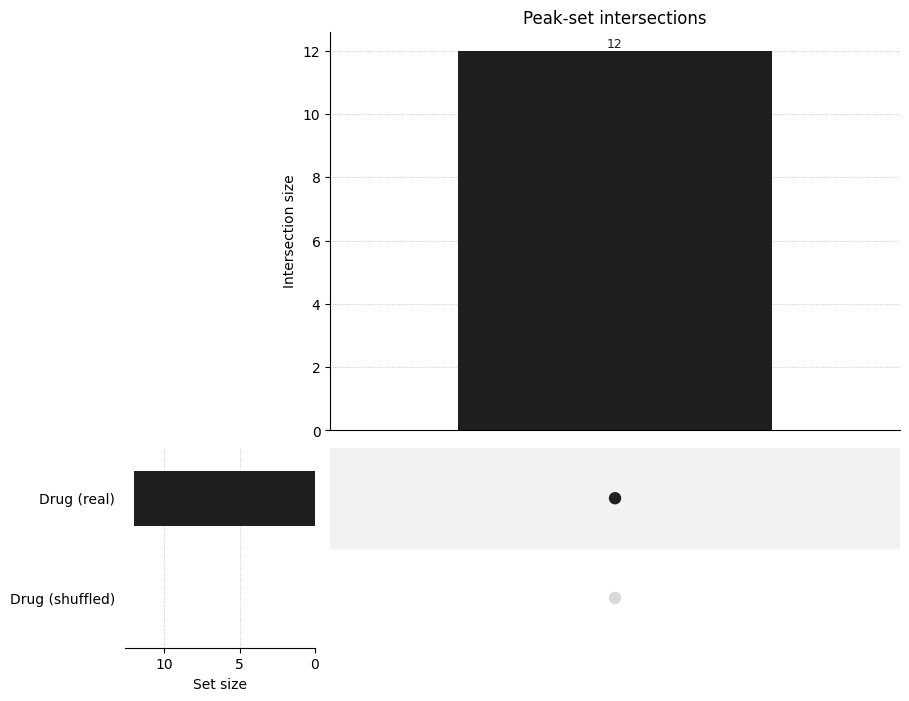

In [12]:
_ = plot_drug_comparison(comparison, kind="upset", title="Peak-set intersections")

## Choosing a Test and Correction

`DifferentialAnalysis.run()` accepts both plain strings and the
`StatisticalTest` / `CorrectionMethod` enums:

| `test`           | When to use                                                          |
| ---------------- | -------------------------------------------------------------------- |
| `mann_whitney`   | Default. Non-parametric, robust to MALDI intensity distributions.    |
| `t_test`         | Welch's t-test (unequal variances). Use for approximately-Gaussian data. |

| `correction`   | Meaning                                                          |
| -------------- | ---------------------------------------------------------------- |
| `fdr_bh`       | Benjamini-Hochberg FDR. Good default.                             |
| `fdr_by`       | Benjamini-Yekutieli FDR. More conservative under dependence.      |
| `bonferroni`   | Family-wise error control. Most conservative.                     |

Example of a conservative configuration:

In [13]:
analysis_strict = DifferentialAnalysis(X, y).run(
    test="t_test",
    correction="bonferroni",
)
analysis_strict.top_peaks(n=5)

,mz_bin,mean_r,mean_s,fold_change,p_value,adjusted_p_value,effect_size
4780,16340.0,0.010394,0.000066,7.297076,6.927491e-26,4.156494e-22,3.268696
4721,16163.0,0.010407,0.000070,7.210103,7.035256e-26,4.221153e-22,3.267646
4826,16478.0,0.010398,0.000063,7.364606,7.576054e-26,4.545632e-22,3.262958
4992,16976.0,0.010403,0.000073,7.152162,7.852392e-26,4.711435e-22,3.260642
1198,5594.0,0.010430,0.000110,6.572977,9.256413e-26,5.553848e-22,3.249831


## Optional: Scoping Filters

When you already know which m/z regions matter, or you want to limit the
hypothesis burden, pass `mz_ranges` and/or `peak_detector` to `run()`:

In [14]:
# Restrict testing to two m/z windows AND require bins to be peaks
# in at least one spectrum.
scoped = DifferentialAnalysis(X, y).run(
    mz_ranges=[(3000, 6000), (9000, 12000)],
    peak_detector=MaldiPeakDetector(method="local", binary=True, prominence=1e-4),
)
print(f"Bins tested (scoped):   {len(scoped.results)}")
print(f"Bins tested (full run): {len(analysis.results)}")
print(f"#adj <= 0.05 (scoped):  {(scoped.results['adjusted_p_value'] <= 0.05).sum()}")

Bins tested (scoped):   1939
Bins tested (full run): 6000
#adj <= 0.05 (scoped):  4


## See Also

- [API Reference - Differential](https://maldiamrkit.readthedocs.io/api/differential.html)
- [Exploration notebook](05_exploration.ipynb) for PCA, t-SNE, UMAP, and spectral similarity